In [1]:
import os, random, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image
from PIL import Image


In [2]:
import kagglehub

path = kagglehub.dataset_download("dimensi0n/afhq-512")
print("Path to dataset files:", path)

c:\Users\Андрей\ML\NeuralNetworksLabs\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Андрей\.cache\kagglehub\datasets\dimensi0n\afhq-512\versions\1


In [ ]:
CFG = {
    "data_root": path,           
    "img_size": 64,             
    "classes": ["cat"], 
    "max_per_class": 5000,

    "batch_size": 64,
    "num_epochs": 100,
    "latent_dim": 128,
    "lr": 2e-4,
    "beta1": 0.5,
    "beta2": 0.999,
    "n_critic": 5,              
    "gp_lambda": 10,             
    "seed":42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "save_dir": "gan_results",
    "sample_interval": 5,          
}

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG["seed"])

os.makedirs(CFG["save_dir"], exist_ok=True)
print(f"Device: {CFG['device']}")
if CFG["device"] == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 2060
VRAM: 6.4 GB



Загрузка датасета...
  cat: 5000 изображений
Итого: 5000 изображений



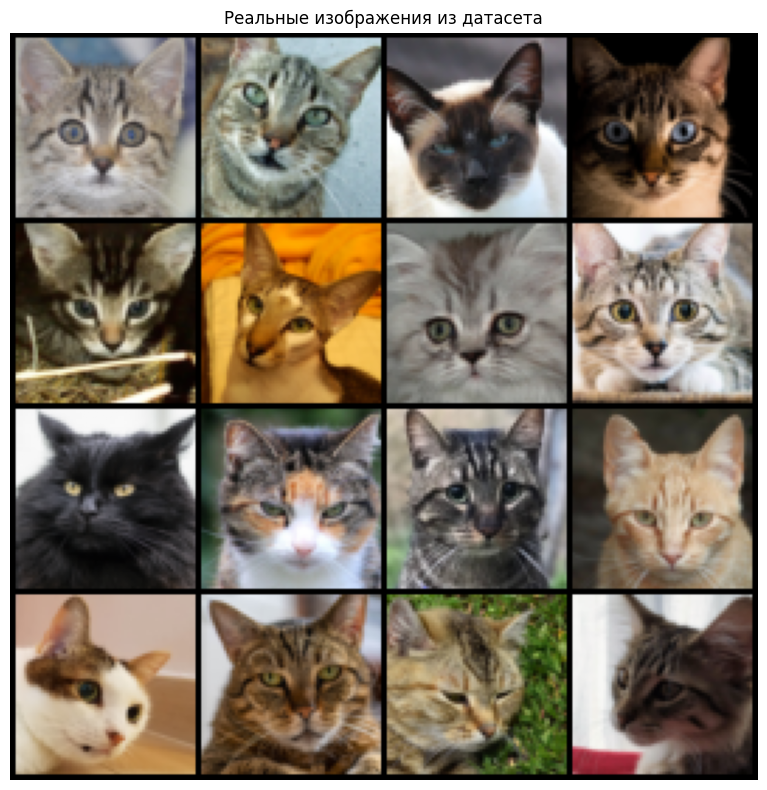

In [ ]:
class AnimalDataset(Dataset):
    def __init__(self, root, classes, img_size, max_per_class=None, transform=None):
        self.samples = []
        self.transform = transform
        for cls in classes:
            cls_dir = Path(root) / cls
            if not cls_dir.exists():
                for sub in ["train", "val", "test"]:
                    alt = Path(root) / sub / cls
                    if alt.exists():
                        cls_dir = alt
                        break
            imgs = sorted(cls_dir.glob("*.png")) + sorted(cls_dir.glob("*.jpg"))
            if max_per_class:
                imgs = imgs[:max_per_class]
            self.samples.extend(imgs)
            print(f"  {cls}: {len(imgs)} изображений")

        if transform is None:
            self.transform = transforms.Compose([
                transforms.Resize(int(img_size * 1.1)),
                transforms.RandomCrop(img_size),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # → [-1, 1]
            ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert("RGB")
        return self.transform(img)


print("\nЗагрузка датасета...")
dataset = AnimalDataset(
    root=CFG["data_root"],
    classes=CFG["classes"],
    img_size=CFG["img_size"],
    max_per_class=CFG["max_per_class"],
)
print(f"Итого: {len(dataset)} изображений\n")

dataloader = DataLoader(
    dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
)

def show_batch(dataloader, n=16, title="Реальные изображения"):
    imgs, _ = next(iter(dataloader)), None
    if isinstance(imgs, (list, tuple)):
        imgs = imgs[0]
    imgs = imgs[:n]
    grid = make_grid(imgs * 0.5 + 0.5, nrow=4, padding=2)
    plt.figure(figsize=(8, 8))
    plt.title(title)
    plt.axis("off")
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.tight_layout()
    plt.savefig(f"{CFG['save_dir']}/real_samples.png", dpi=100)
    plt.show()

show_batch(dataloader, title="Реальные изображения из датасета")

In [ ]:
def weights_init(m):
    cname = m.__class__.__name__
    if "Conv" in cname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

def save_samples(generator, fixed_noise, epoch, arch_name, device):
    generator.eval()
    with torch.no_grad():
        fake = generator(fixed_noise.to(device)).cpu()
    grid = make_grid(fake * 0.5 + 0.5, nrow=8, padding=2)
    save_image(grid, f"{CFG['save_dir']}/{arch_name}_epoch{epoch:03d}.png")
    generator.train()
    return grid

def plot_losses(g_losses, d_losses, arch_name):
    plt.figure(figsize=(10, 4))
    plt.plot(g_losses, label="Generator Loss", color="#e74c3c")
    plt.plot(d_losses, label="Discriminator Loss", color="#3498db")
    plt.xlabel("Итерация")
    plt.ylabel("Потери")
    plt.title(f"Кривые потерь — {arch_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{CFG['save_dir']}/{arch_name}_losses.png", dpi=100)
    plt.show()

In [ ]:
class DCGAN_Generator(nn.Module):
    def __init__(self, latent_dim, img_size):
        super().__init__()
        self.init_size = 4
        n_upsample = int(np.log2(img_size)) - 2

        self.fc = nn.Linear(latent_dim, 512 * 4 * 4)

        layers = []
        in_ch = 512
        out_ch = 256
        for i in range(n_upsample - 1):
            layers += [
                nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(True),
            ]
            in_ch = out_ch
            out_ch = max(out_ch // 2, 32)
        layers += [
            nn.ConvTranspose2d(in_ch, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, z):
        x = self.fc(z).view(z.size(0), 512, 4, 4)
        return self.model(x)


class DCGAN_Discriminator(nn.Module):
    def __init__(self, img_size):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d(4)
        self.head = nn.Sequential(
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x).view(-1)


def train_dcgan(dataloader, cfg):
    device = cfg["device"]
    G = DCGAN_Generator(cfg["latent_dim"], cfg["img_size"]).to(device)
    D = DCGAN_Discriminator(cfg["img_size"]).to(device)
    G.apply(weights_init)
    D.apply(weights_init)

    opt_G = optim.Adam(G.parameters(), lr=cfg["lr"], betas=(cfg["beta1"], cfg["beta2"]))
    opt_D = optim.Adam(D.parameters(), lr=cfg["lr"], betas=(cfg["beta1"], cfg["beta2"]))
    criterion = nn.BCELoss()

    fixed_noise = torch.randn(64, cfg["latent_dim"])
    g_losses, d_losses = [], []

    print("\n" + "="*60)
    print("АРХИТЕКТУРА 1: DCGAN")
    print("="*60)

    for epoch in range(1, cfg["num_epochs"] + 1):
        G.train(); D.train()
        ep_g, ep_d = [], []

        for real in tqdm(dataloader, desc=f"Epoch {epoch}/{cfg['num_epochs']}"):
            real = real.to(device)
            bs = real.size(0)
            real_labels = torch.ones(bs, device=device)
            fake_labels = torch.zeros(bs, device=device)

            opt_D.zero_grad()
            d_real = D(real)
            loss_d_real = criterion(d_real, real_labels)

            z = torch.randn(bs, cfg["latent_dim"], device=device)
            fake = G(z).detach()
            d_fake = D(fake)
            loss_d_fake = criterion(d_fake, fake_labels)

            loss_D = (loss_d_real + loss_d_fake) / 2
            loss_D.backward()
            opt_D.step()

            opt_G.zero_grad()
            z = torch.randn(bs, cfg["latent_dim"], device=device)
            fake = G(z)
            g_out = D(fake)
            loss_G = criterion(g_out, real_labels)
            loss_G.backward()
            opt_G.step()

            ep_g.append(loss_G.item())
            ep_d.append(loss_D.item())

        g_losses.extend(ep_g)
        d_losses.extend(ep_d)
        print(f"  G Loss: {np.mean(ep_g):.4f} | D Loss: {np.mean(ep_d):.4f}")

        if epoch % cfg["sample_interval"] == 0 or epoch == cfg["num_epochs"]:
            save_samples(G, fixed_noise, epoch, "DCGAN", device)

    plot_losses(g_losses, d_losses, "DCGAN")
    torch.save(G.state_dict(), f"{cfg['save_dir']}/DCGAN_generator.pth")
    return G, g_losses, d_losses

In [ ]:
class WGAN_Generator(nn.Module):
    def __init__(self, latent_dim, img_size):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 4 * 4)
        n_upsample = int(np.log2(img_size)) - 2

        layers = []
        in_ch = 512
        out_ch = 256
        for i in range(n_upsample - 1):
            layers += [
                nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False),
                nn.InstanceNorm2d(out_ch, affine=True),
                nn.ReLU(True),
            ]
            in_ch = out_ch
            out_ch = max(out_ch // 2, 32)
        layers += [
            nn.ConvTranspose2d(in_ch, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, z):
        x = self.fc(z).view(z.size(0), 512, 4, 4)
        return self.model(x)


class WGAN_Critic(nn.Module):
    def __init__(self, img_size):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(128, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(256, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(512, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d(4)
        self.head = nn.Conv2d(512, 1, 4, 1, 0, bias=False)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x).view(-1)


def gradient_penalty(critic, real, fake, device):
    bs = real.size(0)
    alpha = torch.rand(bs, 1, 1, 1, device=device).expand_as(real)
    interpolated = (alpha * real + (1 - alpha) * fake.detach()).requires_grad_(True)

    c_interp = critic(interpolated)
    grad = torch.autograd.grad(
        outputs=c_interp,
        inputs=interpolated,
        grad_outputs=torch.ones_like(c_interp),
        create_graph=True,
        retain_graph=True,
    )[0]
    grad_norm = grad.view(bs, -1).norm(2, dim=1)
    return ((grad_norm - 1) ** 2).mean()


def train_wgan_gp(dataloader, cfg):
    device = cfg["device"]
    G = WGAN_Generator(cfg["latent_dim"], cfg["img_size"]).to(device)
    C = WGAN_Critic(cfg["img_size"]).to(device)
    G.apply(weights_init)
    C.apply(weights_init)

    opt_G = optim.Adam(G.parameters(), lr=1e-4, betas=(0.0, 0.9))
    opt_C = optim.Adam(C.parameters(), lr=1e-4, betas=(0.0, 0.9))

    fixed_noise = torch.randn(64, cfg["latent_dim"])
    g_losses, d_losses = [], []

    print("\n" + "="*60)
    print("АРХИТЕКТУРА 2: WGAN-GP")
    print("="*60)

    for epoch in range(1, cfg["num_epochs"] + 1):
        G.train(); C.train()
        ep_g, ep_d = [], []
        data_iter = iter(dataloader)

        for i in range(len(dataloader) // (cfg["n_critic"] + 1)):
            for _ in range(cfg["n_critic"]):
                try:
                    real = next(data_iter).to(device)
                except StopIteration:
                    data_iter = iter(dataloader)
                    real = next(data_iter).to(device)

                bs = real.size(0)
                z = torch.randn(bs, cfg["latent_dim"], device=device)
                fake = G(z).detach()

                opt_C.zero_grad()
                loss_C = -C(real).mean() + C(fake).mean()
                gp = gradient_penalty(C, real, fake, device)
                loss_total_C = loss_C + cfg["gp_lambda"] * gp
                loss_total_C.backward()
                opt_C.step()
                ep_d.append(loss_C.item())

            opt_G.zero_grad()
            z = torch.randn(bs, cfg["latent_dim"], device=device)
            loss_G = -C(G(z)).mean()
            loss_G.backward()
            opt_G.step()
            ep_g.append(loss_G.item())

        g_losses.extend(ep_g)
        d_losses.extend(ep_d)
        print(f"  Epoch {epoch}/{cfg['num_epochs']} | G Loss: {np.mean(ep_g):.4f} | W-dist: {-np.mean(ep_d):.4f}")

        if epoch % cfg["sample_interval"] == 0 or epoch == cfg["num_epochs"]:
            save_samples(G, fixed_noise, epoch, "WGANGP", device)

    plot_losses(g_losses, d_losses, "WGAN-GP")
    torch.save(G.state_dict(), f"{cfg['save_dir']}/WGANGP_generator.pth")
    return G, g_losses, d_losses

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3, 1, 0, bias=False),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3, 1, 0, bias=False),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)


class ResNet_Generator(nn.Module):
    def __init__(self, latent_dim, img_size, n_res=6):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)
        n_upsample = int(np.log2(img_size)) - 2

        self.encoder = nn.Sequential(
            nn.Conv2d(256, 256, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(256),
            nn.ReLU(True),
        )
        self.res_blocks = nn.Sequential(*[ResBlock(256) for _ in range(n_res)])

        layers = []
        in_ch = 256
        out_ch = 128
        for i in range(n_upsample - 1):
            layers += [
                nn.Upsample(scale_factor=2),
                nn.Conv2d(in_ch, out_ch, 3, 1, 1, bias=False),
                nn.InstanceNorm2d(out_ch),
                nn.ReLU(True),
            ]
            in_ch = out_ch
            out_ch = max(out_ch // 2, 32)
        layers += [
            nn.Upsample(scale_factor=2),
            nn.Conv2d(in_ch, 3, 7, 1, 3, bias=False),
            nn.Tanh(),
        ]
        self.decoder = nn.Sequential(*layers)

    def forward(self, z):
        x = self.fc(z).view(z.size(0), 256, 4, 4)
        x = self.encoder(x)
        x = self.res_blocks(x)
        return self.decoder(x)


class PatchGAN_Discriminator(nn.Module):
    def __init__(self, img_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 1, 1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 1),
        )

    def forward(self, x):
        return self.model(x)


def train_resnet_gan(dataloader, cfg):
    device = cfg["device"]
    G = ResNet_Generator(cfg["latent_dim"], cfg["img_size"]).to(device)
    D = PatchGAN_Discriminator(cfg["img_size"]).to(device)
    G.apply(weights_init)
    D.apply(weights_init)

    opt_G = optim.Adam(G.parameters(), lr=cfg["lr"], betas=(cfg["beta1"], cfg["beta2"]))
    opt_D = optim.Adam(D.parameters(), lr=cfg["lr"], betas=(cfg["beta1"], cfg["beta2"]))

    criterion_mse = nn.MSELoss()
    criterion_l1  = nn.L1Loss()

    fixed_noise = torch.randn(64, cfg["latent_dim"])
    g_losses, d_losses = [], []

    print("\n" + "="*60)
    print("АРХИТЕКТУРА 3: ResNet-GAN + PatchGAN")
    print("="*60)

    for epoch in range(1, cfg["num_epochs"] + 1):
        G.train(); D.train()
        ep_g, ep_d = [], []

        for real in tqdm(dataloader, desc=f"Epoch {epoch}/{cfg['num_epochs']}"):
            real = real.to(device)
            bs = real.size(0)

            patch_shape = D(real).shape
            real_labels = torch.ones(patch_shape, device=device)
            fake_labels = torch.zeros(patch_shape, device=device)

            opt_D.zero_grad()
            loss_D_real = criterion_mse(D(real), real_labels)
            z = torch.randn(bs, cfg["latent_dim"], device=device)
            fake = G(z).detach()
            loss_D_fake = criterion_mse(D(fake), fake_labels)
            loss_D = (loss_D_real + loss_D_fake) / 2
            loss_D.backward()
            opt_D.step()

            opt_G.zero_grad()
            z = torch.randn(bs, cfg["latent_dim"], device=device)
            fake = G(z)
            patch_shape_g = D(fake).shape
            real_labels_g = torch.ones(patch_shape_g, device=device)

            loss_adv = criterion_mse(D(fake), real_labels_g)
            loss_fm = criterion_l1(fake.mean(0), real.mean(0)) * 10
            loss_G = loss_adv + loss_fm
            loss_G.backward()
            opt_G.step()

            ep_g.append(loss_G.item())
            ep_d.append(loss_D.item())

        g_losses.extend(ep_g)
        d_losses.extend(ep_d)
        print(f"  G Loss: {np.mean(ep_g):.4f} | D Loss: {np.mean(ep_d):.4f}")

        if epoch % cfg["sample_interval"] == 0 or epoch == cfg["num_epochs"]:
            save_samples(G, fixed_noise, epoch, "ResNetGAN", device)

    plot_losses(g_losses, d_losses, "ResNet-GAN")
    torch.save(G.state_dict(), f"{cfg['save_dir']}/ResNetGAN_generator.pth")
    return G, g_losses, d_losses


АРХИТЕКТУРА 1: DCGAN


Epoch 1/100: 100%|██████████| 78/78 [01:02<00:00,  1.25it/s]


  G Loss: 9.5908 | D Loss: 0.1859


Epoch 2/100: 100%|██████████| 78/78 [00:48<00:00,  1.59it/s]


  G Loss: 6.0937 | D Loss: 0.2900


...

  G Loss: 3.3973 | D Loss: 0.2299


Epoch 99/100: 100%|██████████| 78/78 [00:48<00:00,  1.59it/s]


  G Loss: 3.3276 | D Loss: 0.1575


Epoch 100/100: 100%|██████████| 78/78 [00:49<00:00,  1.58it/s]


  G Loss: 3.4231 | D Loss: 0.1390


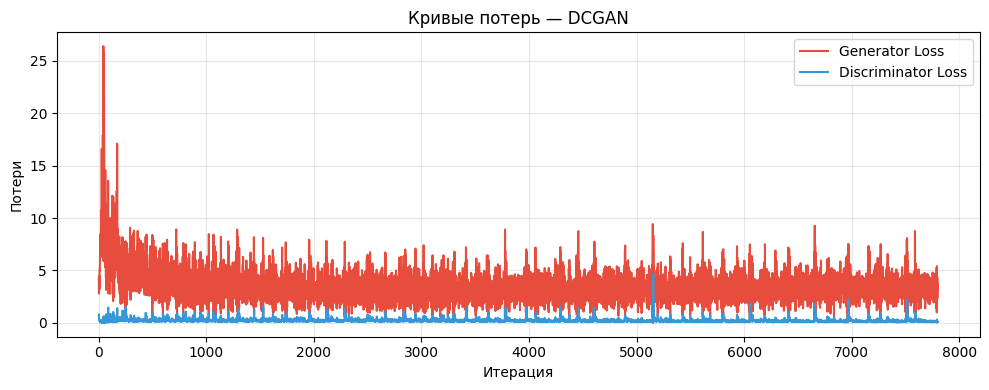


АРХИТЕКТУРА 2: WGAN-GP
  Epoch 1/100 | G Loss: 4.2485 | W-dist: 3.1307
  Epoch 2/100 | G Loss: 8.0431 | W-dist: 7.0907
  Epoch 3/100 | G Loss: 10.3664 | W-dist: 12.1556
  Epoch 4/100 | G Loss: 12.2438 | W-dist: 14.6010
  Epoch 5/100 | G Loss: 15.1906 | W-dist: 16.0046
  Epoch 6/100 | G Loss: 19.0734 | W-dist: 17.7760
  Epoch 7/100 | G Loss: 22.4148 | W-dist: 19.7915
  Epoch 8/100 | G Loss: 24.7423 | W-dist: 21.0878
  Epoch 9/100 | G Loss: 26.1532 | W-dist: 21.6908
  Epoch 10/100 | G Loss: 29.1984 | W-dist: 22.0315
  Epoch 11/100 | G Loss: 29.2906 | W-dist: 21.8921
  Epoch 12/100 | G Loss: 30.8035 | W-dist: 22.3304
  Epoch 13/100 | G Loss: 31.1499 | W-dist: 22.6655
  Epoch 14/100 | G Loss: 31.9425 | W-dist: 23.4884
  Epoch 15/100 | G Loss: 32.8538 | W-dist: 24.1768
  Epoch 16/100 | G Loss: 31.6516 | W-dist: 24.7257
  Epoch 17/100 | G Loss: 32.6604 | W-dist: 25.4176
  Epoch 18/100 | G Loss: 33.6926 | W-dist: 25.2267
  Epoch 19/100 | G Loss: 34.5086 | W-dist: 24.8728
  Epoch 20/100 | G L

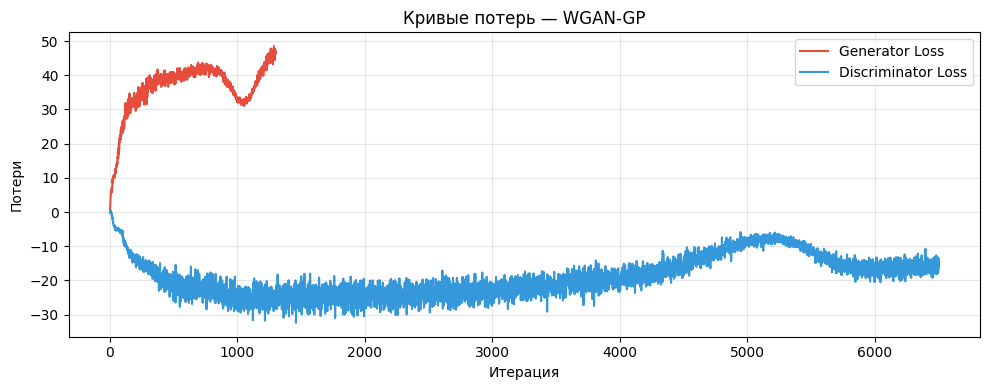


АРХИТЕКТУРА 3: ResNet-GAN + PatchGAN


Epoch 1/100: 100%|██████████| 78/78 [00:55<00:00,  1.40it/s]


  G Loss: 1.8800 | D Loss: 0.5383


Epoch 2/100: 100%|██████████| 78/78 [00:55<00:00,  1.41it/s]


  G Loss: 1.5483 | D Loss: 0.3018


...

  G Loss: 1.5537 | D Loss: 0.1143


Epoch 99/100: 100%|██████████| 78/78 [00:52<00:00,  1.49it/s]


  G Loss: 1.5675 | D Loss: 0.1122


Epoch 100/100: 100%|██████████| 78/78 [00:52<00:00,  1.49it/s]


  G Loss: 1.5954 | D Loss: 0.1241


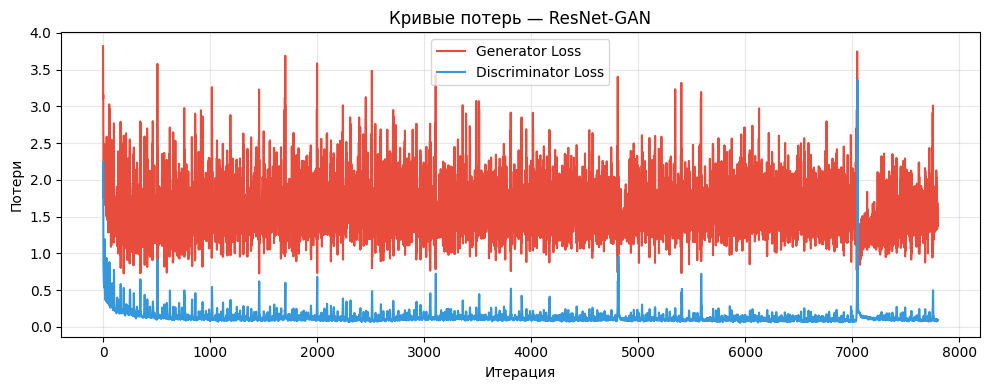

In [9]:
results = {}

# --- DCGAN ---
G1, g1, d1 = train_dcgan(dataloader, CFG)
results["DCGAN"] = {"g_losses": g1, "d_losses": d1, "model": G1}

# --- WGAN-GP ---
G2, g2, d2 = train_wgan_gp(dataloader, CFG)
results["WGAN-GP"] = {"g_losses": g2, "d_losses": d2, "model": G2}

# --- ResNet-GAN ---
G3, g3, d3 = train_resnet_gan(dataloader, CFG)
results["ResNet-GAN"] = {"g_losses": g3, "d_losses": d3, "model": G3}

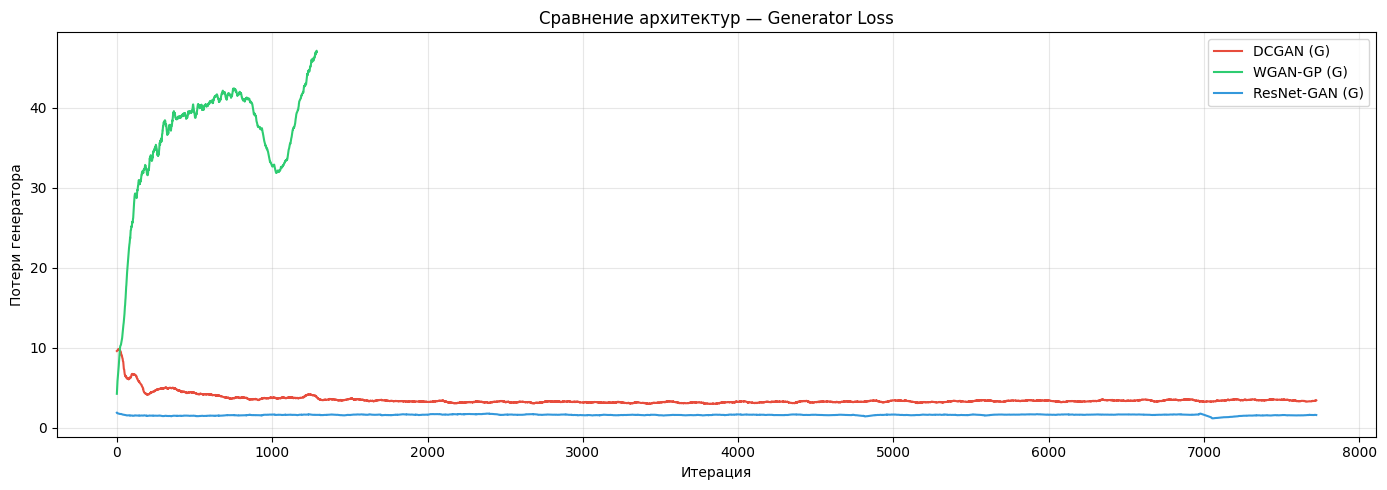

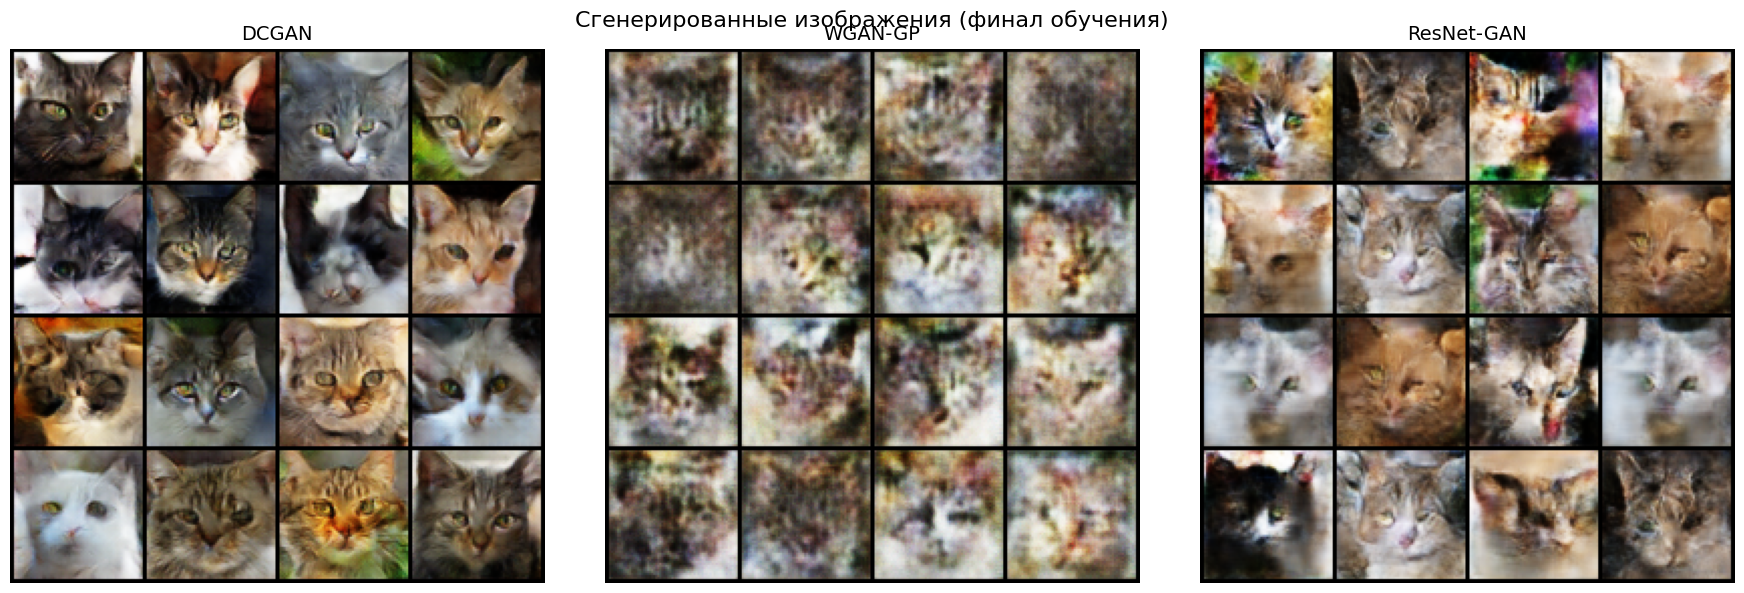


Архитектура     G (финал)       D (финал)       Параметры G    
----------------------------------------------------------------------
DCGAN           3.4921          0.1398          3.81M
WGAN-GP         46.2116         -15.7134        3.81M
ResNet-GAN      1.5904          0.1335          8.59M


In [ ]:
def compare_architectures(results, cfg):
    device = cfg["device"]

    plt.figure(figsize=(14, 5))
    colors = {"DCGAN": "#e74c3c", "WGAN-GP": "#2ecc71", "ResNet-GAN": "#3498db"}
    for name, res in results.items():
        g = np.array(res["g_losses"])
        window = max(1, len(g) // 100)
        smoothed = np.convolve(g, np.ones(window)/window, mode="valid")
        plt.plot(smoothed, label=f"{name} (G)", color=colors[name])
    plt.xlabel("Итерация")
    plt.ylabel("Потери генератора")
    plt.title("Сравнение архитектур — Generator Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{cfg['save_dir']}/comparison_g_losses.png", dpi=100)
    plt.show()

    fixed_noise = torch.randn(16, cfg["latent_dim"])
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, (name, res) in zip(axes, results.items()):
        G = res["model"]
        G.eval()
        with torch.no_grad():
            fake = G(fixed_noise.to(device)).cpu()
        grid = make_grid(fake * 0.5 + 0.5, nrow=4, padding=2)
        ax.imshow(grid.permute(1, 2, 0).numpy())
        ax.set_title(name, fontsize=14)
        ax.axis("off")
    plt.suptitle("Сгенерированные изображения (финал обучения)", fontsize=16)
    plt.tight_layout()
    plt.savefig(f"{cfg['save_dir']}/comparison_generated.png", dpi=100)
    plt.show()

    print("\n" + "="*70)
    print(f"{'Архитектура':<15} {'G (финал)':<15} {'D (финал)':<15} {'Параметры G':<15}")
    print("-"*70)
    for name, res in results.items():
        g_final = np.mean(res["g_losses"][-50:])
        d_final = np.mean(res["d_losses"][-50:])
        params = sum(p.numel() for p in res["model"].parameters()) / 1e6
        print(f"{name:<15} {g_final:<15.4f} {d_final:<15.4f} {params:.2f}M")
    print("="*70)


compare_architectures(results, CFG)


Оценка дискриминаторов

DCGAN:
  Real  — mean: -0.1387, std: 0.4974
  Fake  — mean: -0.1741, std: 0.5200
  |Δmean|: 0.0354  (ближе к 0 = лучше)

WGAN-GP:
  Real  — mean: -0.1387, std: 0.4974
  Fake  — mean: -0.1108, std: 0.4104
  |Δmean|: 0.0279  (ближе к 0 = лучше)

ResNet-GAN:
  Real  — mean: -0.1387, std: 0.4974
  Fake  — mean: -0.0697, std: 0.4864
  |Δmean|: 0.0690  (ближе к 0 = лучше)


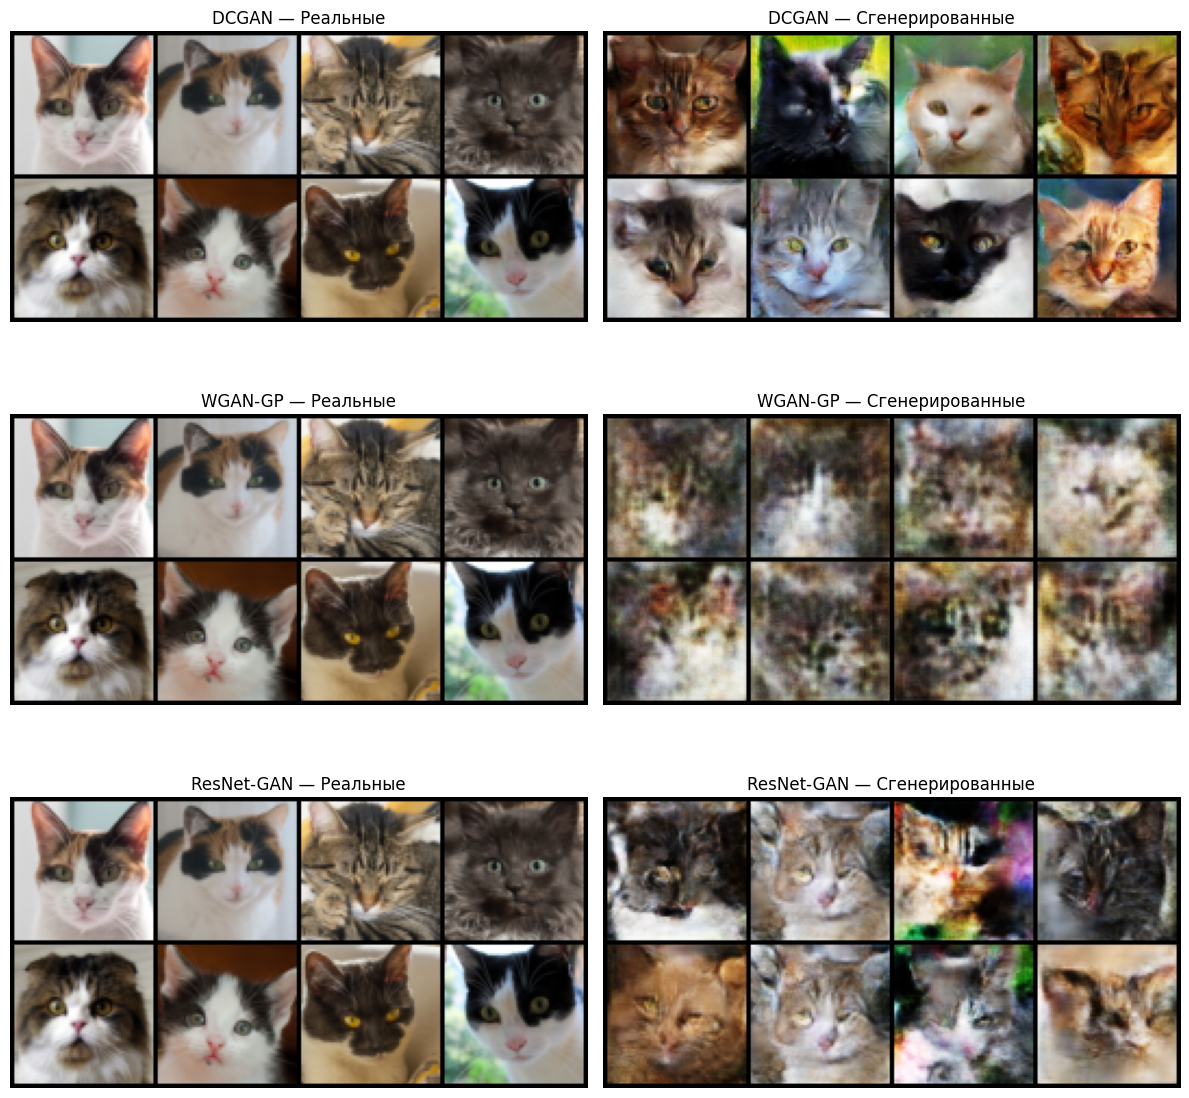


 Все результаты сохранены в папку: gan_results/
Файлы:
  comparison_g_losses.png
  comparison_generated.png
  DCGAN_epoch005.png
  DCGAN_epoch010.png
  DCGAN_epoch015.png
  DCGAN_epoch020.png
  DCGAN_epoch025.png
  DCGAN_epoch030.png
  DCGAN_epoch035.png
  DCGAN_epoch040.png
  DCGAN_epoch045.png
  DCGAN_epoch050.png
  DCGAN_epoch055.png
  DCGAN_epoch060.png
  DCGAN_epoch065.png
  DCGAN_epoch070.png
  DCGAN_epoch075.png
  DCGAN_epoch080.png
  DCGAN_epoch085.png
  DCGAN_epoch090.png
  DCGAN_epoch095.png
  DCGAN_epoch100.png
  DCGAN_generator.pth
  DCGAN_losses.png
  real_samples.png
  real_vs_fake.png
  ResNet-GAN_losses.png
  ResNetGAN_epoch005.png
  ResNetGAN_epoch010.png
  ResNetGAN_epoch015.png
  ResNetGAN_epoch020.png
  ResNetGAN_epoch025.png
  ResNetGAN_epoch030.png
  ResNetGAN_epoch035.png
  ResNetGAN_epoch040.png
  ResNetGAN_epoch045.png
  ResNetGAN_epoch050.png
  ResNetGAN_epoch055.png
  ResNetGAN_epoch060.png
  ResNetGAN_epoch065.png
  ResNetGAN_epoch070.png
  ResNetGAN_epoch0

In [ ]:
def evaluate_discriminator(results, dataloader, cfg):
    device = cfg["device"]

    real_batch = next(iter(dataloader)).to(device)[:16]

    print("\n" + "="*60)
    print("Оценка дискриминаторов")
    print("="*60)

    for name, res in results.items():
        G = res["model"]
        G.eval()
        with torch.no_grad():
            z = torch.randn(16, cfg["latent_dim"], device=device)
            fake_batch = G(z)

        real_mean = real_batch.mean().item()
        fake_mean = fake_batch.mean().item()
        real_std  = real_batch.std().item()
        fake_std  = fake_batch.std().item()

        print(f"\n{name}:")
        print(f"  Real  — mean: {real_mean:+.4f}, std: {real_std:.4f}")
        print(f"  Fake  — mean: {fake_mean:+.4f}, std: {fake_std:.4f}")
        print(f"  |Δmean|: {abs(real_mean - fake_mean):.4f}  (ближе к 0 = лучше)")

    fig, axes = plt.subplots(len(results), 2, figsize=(12, 4*len(results)))
    for i, (name, res) in enumerate(results.items()):
        G = res["model"]
        G.eval()
        with torch.no_grad():
            z = torch.randn(8, cfg["latent_dim"], device=device)
            fake = G(z).cpu()

        real_grid = make_grid(real_batch[:8].cpu() * 0.5 + 0.5, nrow=4)
        fake_grid = make_grid(fake * 0.5 + 0.5, nrow=4)

        axes[i, 0].imshow(real_grid.permute(1,2,0).numpy())
        axes[i, 0].set_title(f"{name} — Реальные")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(fake_grid.permute(1,2,0).numpy())
        axes[i, 1].set_title(f"{name} — Сгенерированные")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.savefig(f"{cfg['save_dir']}/real_vs_fake.png", dpi=100)
    plt.show()


evaluate_discriminator(results, dataloader, CFG)

print(f"\n Все результаты сохранены в папку: {CFG['save_dir']}/")
print("Файлы:")
for f in sorted(Path(CFG["save_dir"]).glob("*")):
    print(f"  {f.name}")